In [117]:
from autograd import grad, elementwise_grad
import autograd.numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from NeuralNetwork import NeuralNetwork
from functions import *
from Scheduler import Adam

In [118]:
def runge_func(x):
    return 1/(1+25*x**2)

In [119]:
xs = np.linspace(-1000, 1000, 10)[:,np.newaxis]
ys = runge_func(xs)

xscaler = StandardScaler()
xs = xscaler.fit_transform(xs)
yscaler = StandardScaler()
ys  = yscaler.fit_transform(ys)

yder = elementwise_grad(runge_func)(xs)
print(np.shape(xs))

(10, 1)


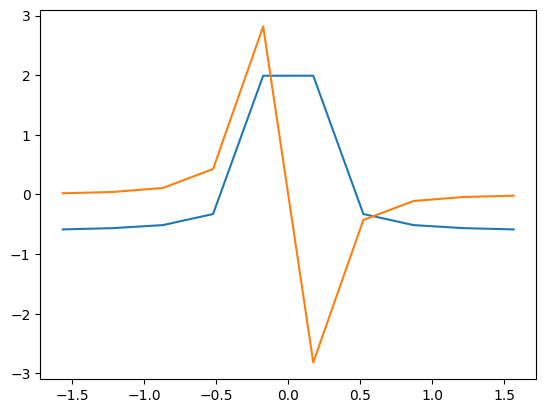

In [120]:
plt.plot(xs, ys)
plt.plot(xs,yder)

In [ ]:
sig_diff = np.abs(elementwise_grad(sigmoid)(xs)-sigmoid_der(xs))
print("sig", np.all(sig_diff < 1e-15))
ReLU_diff = np.abs(elementwise_grad(ReLU)(xs)-ReLU_der(xs))
print("ReLU", np.all(ReLU_diff < 1e-15))
leaky_ReLU_diff = np.abs(elementwise_grad(leaky_ReLU)(xs)-leaky_ReLU_der(xs))
print("leaky ReLU", np.all(leaky_ReLU_diff < 1e-15))
id_diff = np.abs(elementwise_grad(id_func)(xs)-id_func_der(xs))
print("id", np.all(id_diff < 1e-15))

mse_diff = np.abs(grad(mse)(xs,ys) - mse_der(xs,ys))
print("mse_diff", np.all(mse_diff < 1e-15))

In [133]:
n_output = 1
n_input = 1
layer_output_sizes = [1,7, 75, 3]
activation_funcs = [sigmoid, sigmoid, sigmoid, sigmoid, ReLU]
activation_ders = [sigmoid_der, sigmoid_der, sigmoid_der, sigmoid_der, ReLU_der]

scheduler = Adam(0.001)
ffnn = NeuralNetwork(n_input, n_output, layer_output_sizes, activation_funcs, 
                    activation_ders, scheduler, mse, mse_der,
                     regularization = "", reg_param=2e-13, seed = 2025, classifier_mode=False
                    )

In [131]:
weights = ffnn._weights_biases
prediction = ffnn._feed_forward(xs)
grads = ffnn._backpropagation(ys, prediction)

In [135]:
# Purely functional implementation to make autograd easier to work with.
def create_layers(network_input_size, layer_output_sizes):
    layers = []

    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = np.random.randn(i_size, layer_output_size)
        b = np.random.randn(layer_output_size)
        layers.append((W, b))

        i_size = layer_output_size
    return layers


def feed_forward(input, layers, activation_funcs):
    a = input
    for (W, b), activation_func in zip(layers, activation_funcs):
        z = a @ W + b.T
        a = activation_func(z)
    return a


def cost(layers, input, activation_funcs, target):
    predict = feed_forward(input, layers, activation_funcs)
    return mse(predict, target)

def mse_der(predict, target):
    print("MSE", np.shape(predict))
    m = np.shape(predict)[0]
    n = np.shape(predict)[1]
    return 2 / (n*m) * (predict-target)

def feed_forward_saver(input, layers, activation_funcs):
    layer_inputs = []
    zs = []
    a = input
    for (W, b), activation_func in zip(layers, activation_funcs):
        layer_inputs.append(a)
        print("a@w", np.shape(a@W))
        print("b.T", np.shape(b.T))
        z = a @ W + b.T
        a = activation_func(z)

        zs.append(z)

    return layer_inputs, zs, a

def backpropagation(
    input, layers, activation_funcs, target, activation_ders, cost_der=mse_der
):
    layer_inputs, zs, predict = feed_forward_saver(input, layers, activation_funcs)

    layer_grads = [() for layer in layers]
    # We loop over the layers, from the last to the first
    error_current = cost_der(predict,target) * activation_ders[-1](zs[-1])
    W_grad = layer_inputs[-1].T @ error_current 
    b_grad = np.sum(error_current, axis=0)[:,np.newaxis]
    layer_grads[-1] = (W_grad, b_grad)
    error_prev = error_current
    for i in reversed(range(len(layers)-1)):
        act_der = activation_ders[i]
        z = zs[i]
        layer_input = layer_inputs[i]
        W_prev, _ = layers[i+1]
        error_current = error_prev @ W_prev.T * act_der(z)
        W_grad = layer_input.T @ error_current
        b_grad = np.sum(error_current, axis=0)[:,np.newaxis]
        layer_grads[i] = (W_grad, b_grad)
        
        error_prev = error_current
        
    return layer_grads

In [136]:
print(layer_output_sizes)
layer_output_sizes2 = layer_output_sizes + [n_output]
layers = create_layers(n_input, layer_output_sizes2)
layers = ffnn._weights_biases
print("layers", len(layers))
layer_grads = backpropagation(xs, layers, activation_funcs, ys, activation_ders)
print("WEIGHT SHAPES")
for dC_dW, dC_db in layer_grads:
    print("weight", np.shape(dC_dW))
    print("bias", np.shape(dC_db))
    #print("bias\n", dC_db)


[1, 7, 75, 3]
layers 5
a@w (10, 1)
b.T (1, 1)
a@w (10, 7)
b.T (1, 7)
a@w (10, 75)
b.T (1, 75)
a@w (10, 3)
b.T (1, 3)
a@w (10, 1)
b.T (1, 1)
MSE (10, 1)
WEIGHT SHAPES
weight (1, 1)
bias (1, 1)
weight (1, 7)
bias (7, 1)
weight (7, 75)
bias (75, 1)
weight (75, 3)
bias (3, 1)
weight (3, 1)
bias (1, 1)


In [137]:
# Compare Autograd vs Functional implementation
cost_grad = grad(cost,0)
grad_out = cost_grad(layers, xs, activation_funcs, ys)
for i, pair in enumerate(grad_out):
    print(f"\n grad {i}")
    w, b = pair
    w_own,  b_own = layer_grads[i]
    print(np.all(np.abs(w -  w_own) < 1e-15))
    diff = np.abs(b - b_own)
    print(np.all(diff < 1e-15))


 grad 0
True
True

 grad 1
True
True

 grad 2
True
True

 grad 3
True
True

 grad 4
True
True


In [127]:
# Compare Class impl
for i, (w,b) in enumerate(layer_grads):
    print("Layer", i)
    w_own,  b_own = grads[i]
    w_ag, b_ag = grad_out[i]
    
    print("weight", np.shape(w))
    print("bias  ", np.shape(b))
    print("\n")
    #
    # CLASS VS FUNCTIONAL
    #
    #print(np.abs(w - w_own))
    print("Weight same as functional implementation:")
    print(np.all(np.abs(w -  w_own) < 1e-15))
    print("\n")
    
    diff = np.abs(b - b_own)
    print("Bias same as functional implementation:")
    print(np.all(diff < 1e-15))
    print("\n")
    
    #
    # CLASS VS AUTOGRAD
    #
    #print(np.abs(w_ag - w_own))
    print("Weight same as autograd:")
    print(np.all(np.abs(w_ag -  w_own) < 1e-15))
    print("\n")
    
    diff = np.abs(b_ag - b_own)
    print("Bias same as autograd:")
    print(np.all(diff < 1e-15))
    
    
    print("\n------------------------------\n")
    

Layer 0
weight (1, 1)
bias   (1, 1)


Weight same as functional implementation:
True


Bias same as functional implementation:
True


Weight same as autograd:
True


Bias same as autograd:
True

------------------------------

Layer 1
weight (1, 7)
bias   (7, 1)


Weight same as functional implementation:
True


Bias same as functional implementation:
True


Weight same as autograd:
True


Bias same as autograd:
True

------------------------------

Layer 2
weight (7, 75)
bias   (75, 1)


Weight same as functional implementation:
True


Bias same as functional implementation:
True


Weight same as autograd:
True


Bias same as autograd:
True

------------------------------

Layer 3
weight (75, 3)
bias   (3, 1)


Weight same as functional implementation:
True


Bias same as functional implementation:
True


Weight same as autograd:
True


Bias same as autograd:
True

------------------------------

Layer 4
weight (3, 1)
bias   (1, 1)


Weight same as functional implementation:
True


Bi